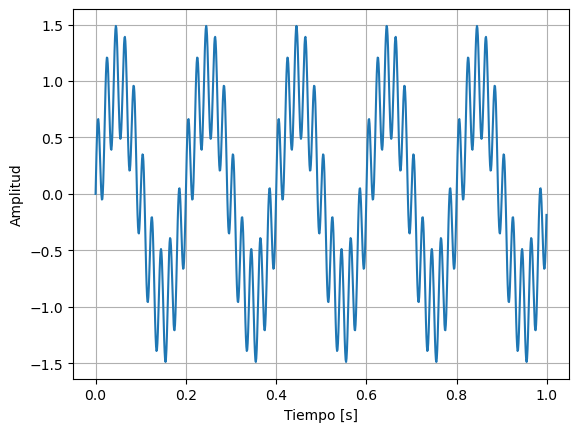

In [ ]:
'''Inciso a)'''
import numpy as np
import matplotlib.pyplot as plt
import time 


# frecuencias de la señal.
f1 = 5
f2 = 50
fs = 1000 # Cantidad de puntos de muestra
t_señal = 1 #duración de la señal en segundos

t_n = np.linspace(0, t_señal, int(t_señal*fs), endpoint= False)

X_n = np.sin(2* np.pi *f1*t_n) + 0.5*np.sin(2* np.pi *f2*t_n)


plt.plot(t_n , X_n)
plt.xlabel('Tiempo [s]')
plt.ylabel('Amplitud')
plt.grid()
plt.show()


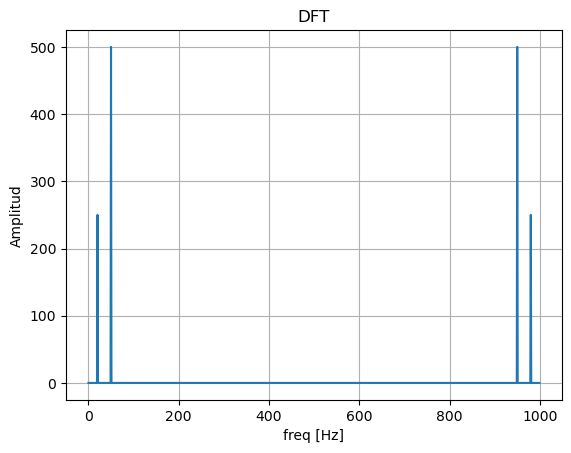

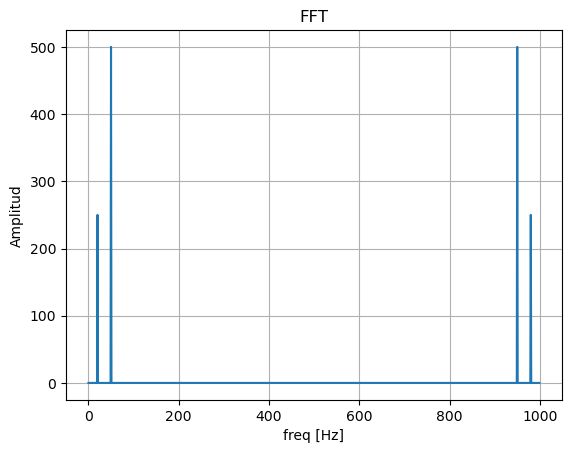

In [23]:
'''Inciso b) y c) (Utiliza las frecuencias f1 y f2 del bloque anterior)'''

def DFT(N):
    X_k = np.zeros(N,dtype=complex)
    Matriz_exp = np.exp(-2j * np.pi * np.arange(N) / N) 
    for k in range(N):
        for n in range(N):
            ind = (k*n)% N # el modulo se aprovecha de la peridodicidad de la exp.
            X_k[k] += X_n[n] * Matriz_exp[ind]
    return X_k

N = len(t_n)
frecuencias = np.arange(N)*(fs/N)
dft =  np.abs(DFT(N))


plt.plot(dft)
plt.title('DFT')
plt.xlabel('freq [Hz]')
plt.ylabel('Amplitud')
plt.grid()
plt.show()

'''Inciso d)'''

fft = np.abs(np.fft.fft(X_n))
plt.plot(fft)
plt.title('FFT')
plt.xlabel('freq [Hz]')
plt.ylabel('Amplitud')
plt.grid()
plt.show()

In [ ]:
'''Inciso e), Aquí mi computador tardo un mónton para 10^5, entonces lo ejecute una vez y guarde los resultados
de los tiempos al final del bloque de código para poder hacer los siguientes incisos.'''

epocas = 10 #Veces que se ejecuta el ciclo while, para tener un promedio de los tiempo de cada transformación, bajalo para 10^4 en adelante.
i = 0
tiempo_dft = 0
tiempo_fft = 0
# frecuencias de la señal.
f1 = 50
f2 = 20
N_s = [10**2,10**3,10**4,10**5] # Lista de Cantidades de puntos de muestra, 
t_n = np.linspace(0, 1, N, endpoint= False)
X_n = np.sin(2* np.pi *f1*t_n) + 0.5*np.sin(2* np.pi *f2*t_n)
tiempos_DFT = []
tiempos_FFT = []

# Eliminar estos ''' y los de abajo para ejecutar el calculo de los tiempos para distintos N's. Despues se tendrían que eliminar las dos listas de más abajo
#para que no se reescriban las listas de tiempo.
'''
for j in range(N_s):
    while i < epocas:
        inicio_dft = time.perf_counter()
        np.abs(DFT(N_s))
        final_dft = time.perf_counter()

        tiempo_dft += final_dft - inicio_dft

        inicio_fft = time.perf_counter()
        np.abs(np.fft.fft(X_n))
        final_fft = time.perf_counter()

        tiempo_fft += final_fft - inicio_fft
        i += 1
    tiempo_dft = round(tiempo_dft/epocas,8)
    tiempo_fft = round(tiempo_fft/epocas,8)
    tiempos_DFT.append(tiempo_dft)
    tiempos_FFT.append(tiempo_fft)
   ''' 


# Estos son los tiempos aprox que salieron del while de arriba, se demora mucho al ejecutar 10^5
# Estos se deben borrar si se busca ejecutar el while.
tiempos_DFT = [0.01186033,1.27129317,100.45465396,4916.05906097]
tiempos_FFT = [1.461*10e-5,4.029*10e-5,0.00037402,0.00463706]

print( "Tiempos para la DFT para N="f"{N_s} respectivamente:",tiempos_FFT)
print( "Tiempos para la FFT para N="f"{N_s} respectivamente:",tiempos_FFT)




Tiempos para la DFT para N=[100, 1000, 10000, 100000] respectivamente: [0.00014610000000000003, 0.00040290000000000004, 0.00037402, 0.00463706]
Tiempos para la FFT para N=[100, 1000, 10000, 100000] respectivamente: [0.00014610000000000003, 0.00040290000000000004, 0.00037402, 0.00463706]


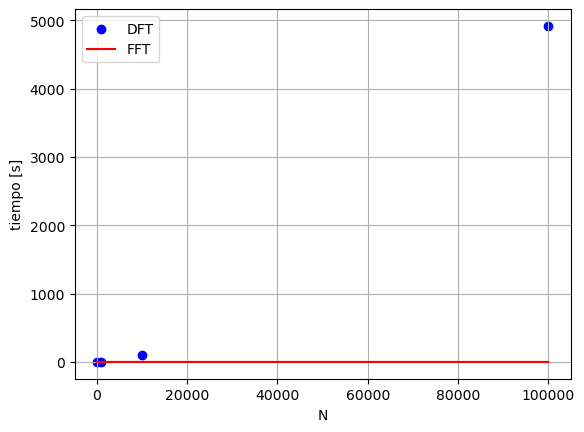

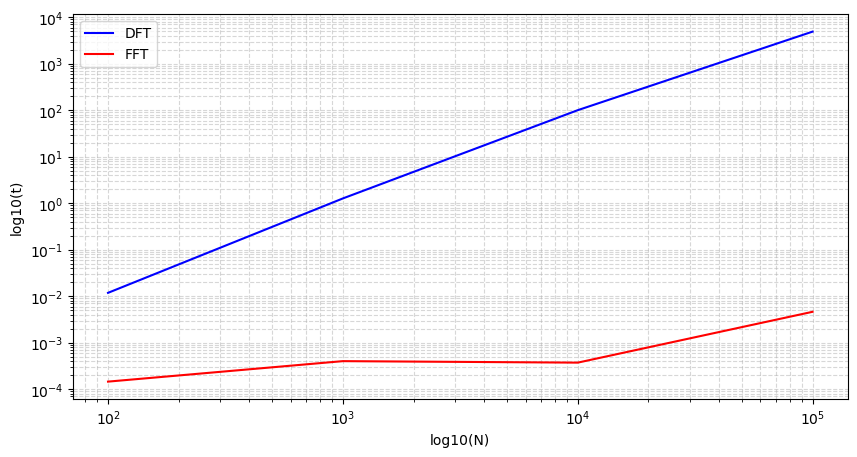

In [26]:
'''Inciso f)'''
plt.scatter(N_s,tiempos_DFT, color= 'blue', label='DFT')
plt.plot(N_s,tiempos_FFT, color= 'red',label='FFT')
plt.legend()
plt.grid()
plt.xlabel('N')
plt.ylabel('tiempo [s]')
plt.show()


'''Inciso g)'''
plt.figure(figsize=(10, 5))
# loglog automáticamente cambia los ejes a base 10
plt.loglog(N_s, tiempos_DFT, label='DFT', color='blue')
plt.loglog(N_s, tiempos_FFT, label='FFT', color='red')
plt.xlabel('log10(N)')
plt.ylabel('log10(t)')
plt.title('')
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.5) 
plt.show()


## Inciso h)

Para este apartado tenemos que $T_{DFT} = 100 *T_{FFT}$ , a esto le aplicamos un $log_{10}$ y queda que :

*(1)* $log_{10}(T_{DFT}) = 2 + log_{10}(T_{FFT})$ 

luego tenemos que al linealizar los tiempos con el logaritmo se cumple para cada uno que:

$log_{10}(T) = \alpha*log_{10}(N) + C$ , con $\alpha$ la pendiente y $C$ el intercepto 

Luego para cada tiempo tenemos:

$log_{10}(T_{DFT}) = \alpha_{DFT}*log_{10}(N) + C_{DFT}$

$log_{10}(T_{FFT}) = \alpha_{FFT}*log_{10}(N) + C_{FFT}$

Reemplazamos en *(1)* 

$\alpha_{DFT}*log_{10}(N) + C_{DFT} = 2 + \alpha_{FFT}*log_{10}(N) + C_{FFT}$

Finalmente despejamos el $log_{10}(N)$

$log_{10}(N) = \frac{2 + C_{FFT} - C{DFT}}{\alpha_{DFT}-\alpha_{FFT}}$


In [ ]:

'''Este bloque es para calcular las pendientes y interceptos de las DFT y FFT'''
log_N = np.log10(N_s)
log_T_dft = np.log10(tiempos_DFT)
log_T_fft = np.log10(tiempos_FFT)
exponente_dft, intercepto_dft = np.polyfit(log_N, log_T_dft, 1)
exponente_fft, intercepto_fft = np.polyfit(log_N, log_T_fft, 1)

print(f"Exponente experimental DFT: {exponente_dft:.2f}")
print(f"Exponente experimental FFT: {exponente_fft:.2f}")

print(f"intercepto experimental DFT: {intercepto_dft:.2f}")
print(f"intercepto experimental FFT: {intercepto_fft:.2f}")

numerador = 2 + intercepto_fft -intercepto_dft
denominador = exponente_dft - exponente_fft
from math import ceil
N = ceil(10**(numerador/denominador)) 
#No usamos round porque ese redondea al entero más cercano, ceil redondea hacia arriba
#Puesto que cómo N es un entero si N = 84.5 entonces pasamos al 85.
print('La FFT se vuelve más 100 veces más rápida para un N = 'f'{N}')

Exponente experimental DFT: 1.88
Exponente experimental FFT: 0.45
intercepto experimental DFT: -5.59
intercepto experimental FFT: -4.81
La FFT se vuelve más 100 veces más rápida para un N = 89


## Inciso i)

El gran aporte de la FFT es pasar de escalar cómo $O(N^2)$ (que es cómo escala la DFT siempre) a escalar cómo $O(Nlog(N))$. Procesar una señal de un millón de puntos, cómo en el inciso e), con una DFT directa requiere de un billón de operaciones. La FFT reduce esta carga a una magnitud que una computadora estándar puede resolver casi instantáneamente. 

